# **1. Perkenalan Dataset**

Dataset yang saya pakai di project ini namanya **Garbage Classification** dari Kaggle. Isinya 15.515 gambar sampah rumah tangga yang udah dikelompokkan jadi **12 kelas**:

| No | Kelas | Contoh |
|---|---|---|
| 1 | `battery` | Baterai bekas |
| 2 | `biological` | Sisa makanan, daun |
| 3 | `brown-glass` | Botol kaca coklat |
| 4 | `cardboard` | Kardus bekas |
| 5 | `clothes` | Pakaian bekas |
| 6 | `green-glass` | Botol kaca hijau |
| 7 | `metal` | Kaleng, logam |
| 8 | `paper` | Kertas, koran |
| 9 | `plastic` | Botol plastik, kantong |
| 10 | `shoes` | Sepatu bekas |
| 11 | `trash` | Sampah campuran |
| 12 | `white-glass` | Botol kaca putih |

**Sumber**: [Kaggle — Garbage Classification](https://www.kaggle.com/datasets/mostafaabla/garbage-classification)

Alasan saya pilih dataset ini karena:
- Jumlah gambarnya lumayan banyak (15K+), jadi model bisa belajar dengan cukup baik
- Kelasnya beragam dan real-world banget, cocok buat latihan klasifikasi gambar
- Resolusinya **beda-beda** (ini yang bikin preprocessing jadi penting banget)

# **2. Import Library**

Di sini saya import semua library yang bakal dipake.
Intinya cuma butuh TensorFlow buat olah gambar, matplotlib/seaborn buat visualisasi, dan PIL buat cek resolusi.

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter
import warnings

# biar gak banyak warning yang ganggu
warnings.filterwarnings('ignore')

# set style plot biar lebih rapih
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print('Library berhasil di-import semua!')

Library berhasil di-import semua!


# **3. Memuat Dataset**

Karena dataset ini berupa gambar (unstructured data), cara loading-nya beda dari CSV biasa. Kita langsung arahkan ke folder dataset yang isinya sudah terstruktur per kelas.

Saya download dulu datasetnya dari Kaggle, terus extract ke folder `raw_data/`.

In [2]:
# path ke folder dataset
# kalau di colab, sesuaikan path-nya
DATASET_DIR = './raw_data/garbage_classification'

# cek dulu ada berapa kelas (subfolder)
kelas_list = sorted([d for d in os.listdir(DATASET_DIR) 
                     if os.path.isdir(os.path.join(DATASET_DIR, d))])

print(f'Total kelas ditemukan: {len(kelas_list)}')
print(f'Nama kelas: {kelas_list}')

Total kelas ditemukan: 12
Nama kelas: ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


In [3]:
# hitung jumlah gambar per kelas
jumlah_per_kelas = {}
total_gambar = 0

for kelas in kelas_list:
    folder = os.path.join(DATASET_DIR, kelas)
    files = [f for f in os.listdir(folder) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    jumlah_per_kelas[kelas] = len(files)
    total_gambar += len(files)

print(f'\nTotal gambar keseluruhan: {total_gambar}')
print('\nDistribusi per kelas:')
for kelas, jml in jumlah_per_kelas.items():
    print(f'  {kelas:15s} : {jml} gambar')


Total gambar keseluruhan: 15515

Distribusi per kelas:
  battery         : 945 gambar
  biological      : 985 gambar
  brown-glass     : 607 gambar
  cardboard       : 891 gambar
  clothes         : 5325 gambar
  green-glass     : 629 gambar
  metal           : 769 gambar
  paper           : 1050 gambar
  plastic         : 865 gambar
  shoes           : 1977 gambar
  trash           : 697 gambar
  white-glass     : 775 gambar


# **4. Exploratory Data Analysis (EDA)**

Ini bagian yang paling seru menurut saya. Di sini kita bakal:
1. Lihat distribusi jumlah gambar per kelas (apakah balance atau imbalance)
2. Cek resolusi gambar — ini yang bikin saya sadar kalau **ukurannya beda-beda banget**
3. Tampilkan sample gambar dari tiap kelas

Ini penting supaya kita tau langkah preprocessing apa yang perlu dilakuin.

## 4.1 Distribusi Jumlah Gambar per Kelas

Pertama, kita cek dulu apakah dataset-nya balanced atau enggak. Kalau imbalanced parah, nanti bisa pengaruhi training model.

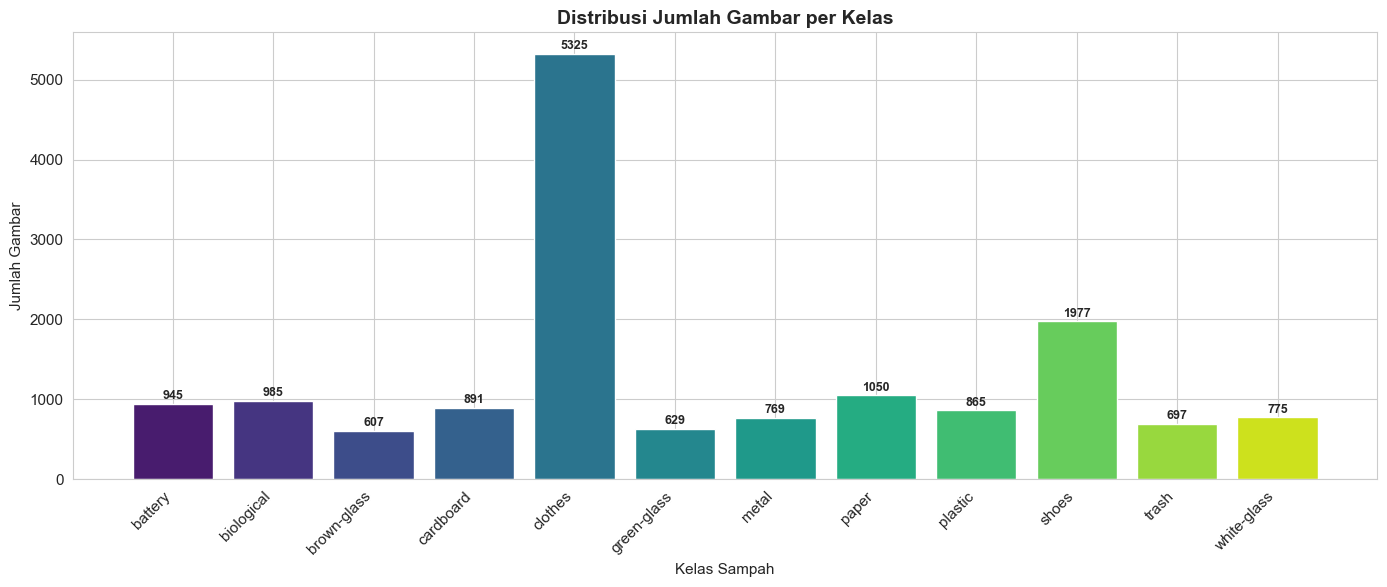


Kelas terbanyak : 5325 gambar
Kelas tersedikit: 607 gambar
Rasio imbalance : 8.77x


In [4]:
# bar chart distribusi kelas
fig, ax = plt.subplots(figsize=(14, 6))

warna = sns.color_palette('viridis', len(kelas_list))
bars = ax.bar(jumlah_per_kelas.keys(), jumlah_per_kelas.values(), color=warna)

# tambahin label angka di atas bar
for bar, jml in zip(bars, jumlah_per_kelas.values()):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            str(jml), ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_title('Distribusi Jumlah Gambar per Kelas', fontsize=14, fontweight='bold')
ax.set_xlabel('Kelas Sampah')
ax.set_ylabel('Jumlah Gambar')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# cek rasio imbalance
max_jml = max(jumlah_per_kelas.values())
min_jml = min(jumlah_per_kelas.values())
print(f'\nKelas terbanyak : {max_jml} gambar')
print(f'Kelas tersedikit: {min_jml} gambar')
print(f'Rasio imbalance : {max_jml/min_jml:.2f}x')

## 4.2 Analisis Resolusi Gambar

Nah ini yang penting banget. Pas pertama kali saya cek, ternyata resolusi gambarnya **beda-beda**. Ada yang 300x225, ada yang 512x384, ada yang square ada yang landscape. Ini yang jadi alasan utama kenapa kita perlu preprocessing resize.

Saya ambil sample acak dari tiap kelas buat dicek resolusinya.

In [5]:
# kumpulkan info resolusi dari sample gambar
resolusi_widths = []
resolusi_heights = []
aspect_ratios = []
sample_per_kelas = 50  # ambil 50 sample acak per kelas biar gak kelamaan

for kelas in kelas_list:
    folder = os.path.join(DATASET_DIR, kelas)
    files = [f for f in os.listdir(folder) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # ambil sample acak
    sampled = random.sample(files, min(sample_per_kelas, len(files)))
    
    for fname in sampled:
        try:
            img = Image.open(os.path.join(folder, fname))
            w, h = img.size
            resolusi_widths.append(w)
            resolusi_heights.append(h)
            aspect_ratios.append(w / h)
        except:
            pass  # skip kalau error

print(f'Total gambar yang dicek: {len(resolusi_widths)}')
print(f'\nStatistik Width:')
print(f'  Min: {min(resolusi_widths)}, Max: {max(resolusi_widths)}, Mean: {np.mean(resolusi_widths):.0f}')
print(f'\nStatistik Height:')
print(f'  Min: {min(resolusi_heights)}, Max: {max(resolusi_heights)}, Mean: {np.mean(resolusi_heights):.0f}')
print(f'\nAspect Ratio:')
print(f'  Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}')
print(f'\n=> Kesimpulan: Resolusi TIDAK seragam, perlu di-resize ke ukuran yang sama!')

Total gambar yang dicek: 600

Statistik Width:
  Min: 133, Max: 865, Mean: 324

Statistik Height:
  Min: 106, Max: 711, Mean: 286

Aspect Ratio:
  Min: 0.35, Max: 4.50

=> Kesimpulan: Resolusi TIDAK seragam, perlu di-resize ke ukuran yang sama!


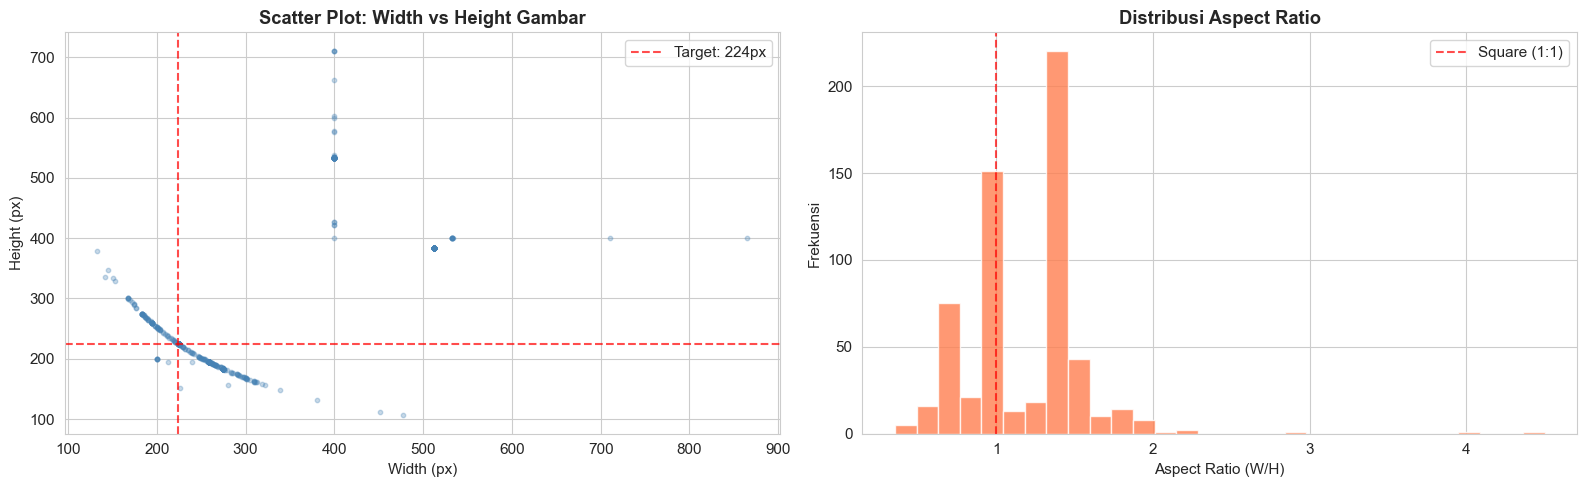

Terlihat jelas resolusinya gak seragam — ini yang jadi dasar kita resize ke 224x224.


In [6]:
# visualisasi scatter plot resolusi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# scatter plot width vs height
axes[0].scatter(resolusi_widths, resolusi_heights, alpha=0.3, s=10, c='steelblue')
axes[0].set_title('Scatter Plot: Width vs Height Gambar', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Height (px)')
axes[0].axhline(y=224, color='red', linestyle='--', alpha=0.7, label='Target: 224px')
axes[0].axvline(x=224, color='red', linestyle='--', alpha=0.7)
axes[0].legend()

# histogram aspect ratio
axes[1].hist(aspect_ratios, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Aspect Ratio', fontweight='bold')
axes[1].set_xlabel('Aspect Ratio (W/H)')
axes[1].set_ylabel('Frekuensi')
axes[1].axvline(x=1.0, color='red', linestyle='--', alpha=0.7, label='Square (1:1)')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Terlihat jelas resolusinya gak seragam — ini yang jadi dasar kita resize ke 224x224.')

## 4.3 Sample Gambar per Kelas

Biar ada gambaran visual, kita tampilkan 1 contoh gambar dari tiap kelas.

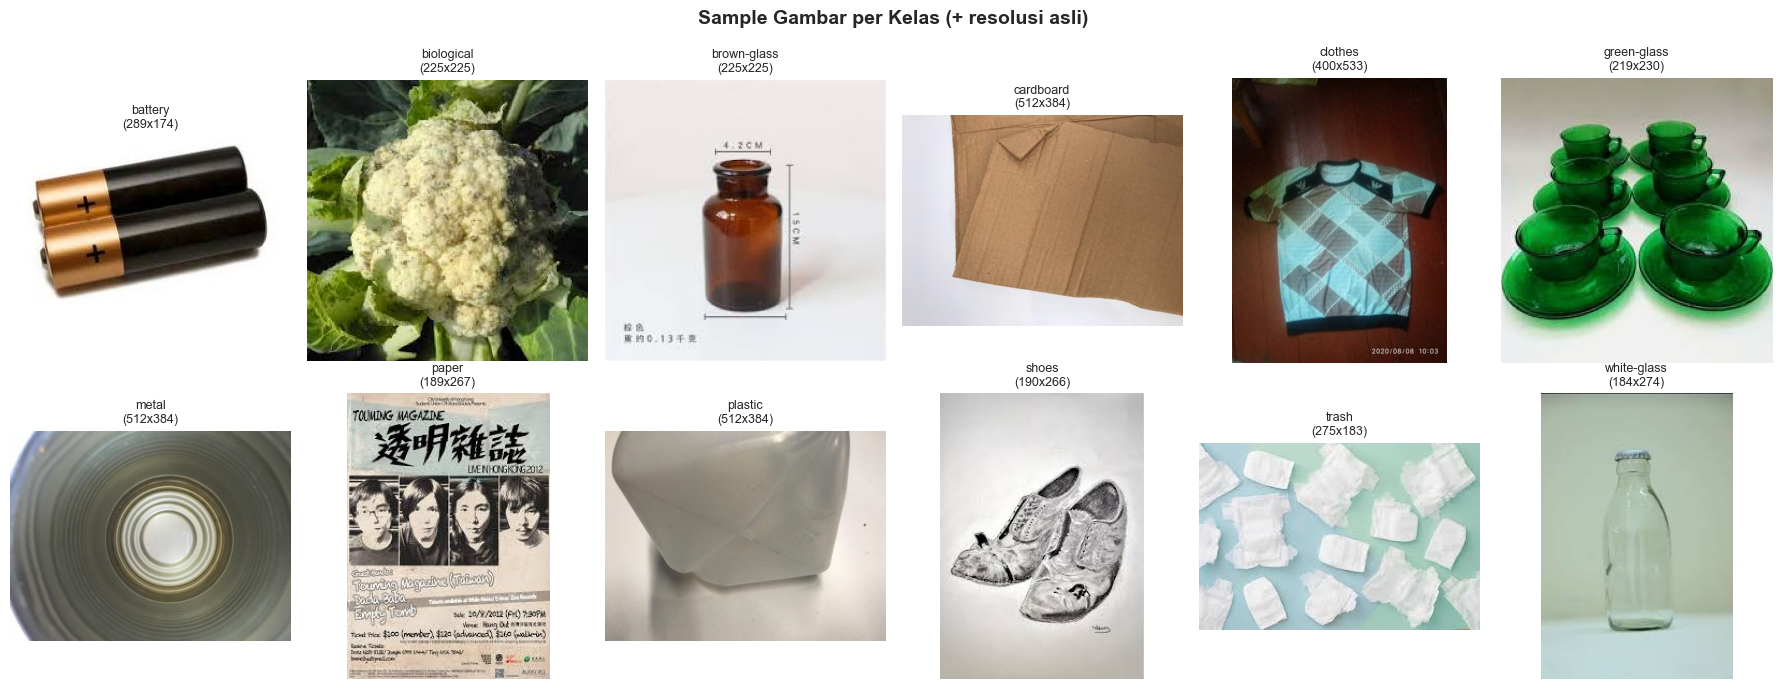

Keliatan kan resolusinya beda-beda? Ada yang landscape, ada yang portrait.


In [7]:
# tampilkan sample gambar per kelas
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
axes = axes.flatten()

for idx, kelas in enumerate(kelas_list):
    folder = os.path.join(DATASET_DIR, kelas)
    files = os.listdir(folder)
    # pilih random 1 gambar
    sample_file = random.choice(files)
    img = Image.open(os.path.join(folder, sample_file))
    
    axes[idx].imshow(img)
    axes[idx].set_title(f'{kelas}\n({img.size[0]}x{img.size[1]})', fontsize=9)
    axes[idx].axis('off')

plt.suptitle('Sample Gambar per Kelas (+ resolusi asli)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Keliatan kan resolusinya beda-beda? Ada yang landscape, ada yang portrait.')

# **5. Data Preprocessing**

Dari hasil EDA di atas, kita udah tau masalah utamanya:
- **Resolusi gambar tidak seragam** — harus di-resize ke ukuran yang sama
- Distribusi kelas lumayan balanced, jadi gak perlu oversampling/undersampling

Langkah preprocessing yang saya lakukan:
1. **Resize** semua gambar ke 224x224 piksel (standar untuk EfficientNetB0)
2. **Normalisasi** pixel value ke range [0, 1] — ini penting buat training neural network
3. **Konversi ke RGB** — pastikan semua gambar 3 channel

Kenapa 224x224? Karena EfficientNetB0 (yang nanti saya pakai buat transfer learning) defaultnya menerima input 224x224. Jadi biar gak perlu resize lagi pas training.

In [8]:
# konfigurasi preprocessing
TARGET_SIZE = (224, 224)
OUTPUT_DIR = './garbage_preprocessing'

# bikin folder output kalau belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Target resize: {TARGET_SIZE[0]}x{TARGET_SIZE[1]} px')
print(f'Output folder: {OUTPUT_DIR}')

Target resize: 224x224 px
Output folder: ./garbage_preprocessing


In [9]:
# proses preprocessing untuk semua gambar
from PIL import Image, UnidentifiedImageError

total_proses = 0
total_gagal = 0

for kelas in kelas_list:
    src_folder = os.path.join(DATASET_DIR, kelas)
    dst_folder = os.path.join(OUTPUT_DIR, kelas)
    os.makedirs(dst_folder, exist_ok=True)
    
    files = [f for f in os.listdir(src_folder) 
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    sukses_kelas = 0
    for fname in files:
        try:
            img_path = os.path.join(src_folder, fname)
            img = Image.open(img_path).convert('RGB')
            
            # resize ke target size
            img_resized = img.resize(TARGET_SIZE, Image.LANCZOS)
            
            # normalisasi ke [0,1] lalu convert balik ke uint8 buat disimpan
            arr = np.array(img_resized, dtype=np.float32) / 255.0
            img_final = Image.fromarray((arr * 255).astype(np.uint8))
            
            # simpan sebagai PNG
            out_name = os.path.splitext(fname)[0] + '.png'
            img_final.save(os.path.join(dst_folder, out_name))
            
            sukses_kelas += 1
            total_proses += 1
        except Exception as e:
            total_gagal += 1
    
    print(f'  {kelas:15s}: {sukses_kelas}/{len(files)} berhasil')

print(f'\n--- Hasil Preprocessing ---')
print(f'Total berhasil : {total_proses}')
print(f'Total gagal    : {total_gagal}')
print(f'\nSemua gambar sudah di-resize ke {TARGET_SIZE[0]}x{TARGET_SIZE[1]} dan dinormalisasi!')

  battery        : 945/945 berhasil


  biological     : 985/985 berhasil


  brown-glass    : 607/607 berhasil


  cardboard      : 891/891 berhasil


  clothes        : 5325/5325 berhasil


...

  paper          : 1050/1050 berhasil


  plastic        : 865/865 berhasil


  shoes          : 1977/1977 berhasil


  trash          : 697/697 berhasil


  white-glass    : 775/775 berhasil

--- Hasil Preprocessing ---
Total berhasil : 15515
Total gagal    : 0

Semua gambar sudah di-resize ke 224x224 dan dinormalisasi!


## Verifikasi Hasil Preprocessing

Sekarang kita cek apakah gambar hasil preprocessing udah bener — ukurannya harus 224x224 semua.

In [10]:
# verifikasi: cek resolusi hasil preprocessing
print('Cek resolusi output (ambil 3 sample per kelas):\n')

all_ok = True
for kelas in kelas_list[:4]:  # cek 4 kelas aja biar gak kepanjangan
    folder = os.path.join(OUTPUT_DIR, kelas)
    if not os.path.exists(folder):
        continue
    files = os.listdir(folder)[:3]
    for fname in files:
        img = Image.open(os.path.join(folder, fname))
        w, h = img.size
        status = '✅' if (w, h) == TARGET_SIZE else '❌'
        if (w, h) != TARGET_SIZE:
            all_ok = False
        print(f'  {status} {kelas}/{fname}: {w}x{h}')

if all_ok:
    print(f'\n✅ Semua gambar sudah 224x224. Preprocessing berhasil!')
else:
    print(f'\n❌ Ada gambar yang belum sesuai, perlu dicek lagi.')

Cek resolusi output (ambil 3 sample per kelas):

  ✅ battery/battery1.png: 224x224
  ✅ battery/battery10.png: 224x224
  ✅ battery/battery100.png: 224x224
  ✅ biological/biological1.png: 224x224
  ✅ biological/biological10.png: 224x224
  ✅ biological/biological100.png: 224x224
  ✅ brown-glass/brown-glass1.png: 224x224
  ✅ brown-glass/brown-glass10.png: 224x224
  ✅ brown-glass/brown-glass100.png: 224x224
  ✅ cardboard/cardboard1.png: 224x224
  ✅ cardboard/cardboard10.png: 224x224
  ✅ cardboard/cardboard100.png: 224x224

✅ Semua gambar sudah 224x224. Preprocessing berhasil!


---

## Catatan Akhir

Dari notebook ini, langkah-langkah yang sudah dilakukan:
1. ✅ Loading dataset Garbage Classification (15.515 gambar, 12 kelas)
2. ✅ EDA — distribusi kelas, analisis resolusi gambar (bukti resolusi tidak seragam)
3. ✅ Preprocessing — resize ke 224x224, normalisasi, konversi RGB

Langkah preprocessing manual di notebook ini sudah saya konversi juga ke script otomatis di file `automate_M._Rohid_Rivaldi.py` yang bisa dijalankan via command line atau GitHub Actions.

**Referensi**:
- Dataset: [Garbage Classification — Kaggle](https://www.kaggle.com/datasets/mostafaabla/garbage-classification)
- EfficientNet: Tan & Le, 2019. "EfficientNet: Rethinking Model Scaling for CNNs"

---
*M. Rohid Rivaldi — rezoku | MSML Dicoding 2026*